# Week 6 - Denoising Autoencoder

## 1. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)
from tensorflow.keras.models import Model

## 2. Load Dataset

In [2]:
def load_images(folder_path):
    images = []
    for digit in os.listdir(folder_path):
        digit_folder = os.path.join(folder_path, digit)
        if not os.path.isdir(digit_folder):
            continue
        for filename in os.listdir(digit_folder):
            img_path = os.path.join(digit_folder, filename)
            img = load_img(
                img_path,
                color_mode='grayscale',
                target_size=(28, 28)
            )
            img = img_to_array(img)
            images.append(img)
    return np.array(images)

## 3. Data Exploration

In [3]:
x_train = load_images("mnist_png/training")
x_test = load_images("mnist_png/testing")
print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

Train shape: (60000, 28, 28, 1)
Test shape : (10000, 28, 28, 1)


## 4. Preprocessing

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(x_train.min(), x_train.max())

0.0 1.0


## 5. Add Noise

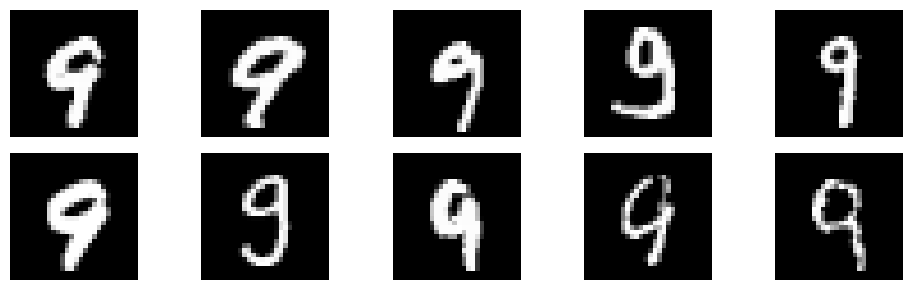

In [5]:
plt.figure(figsize=(10,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
print("Noise added successfully")

Noise added successfully


## 6. Visualize Noisy Images

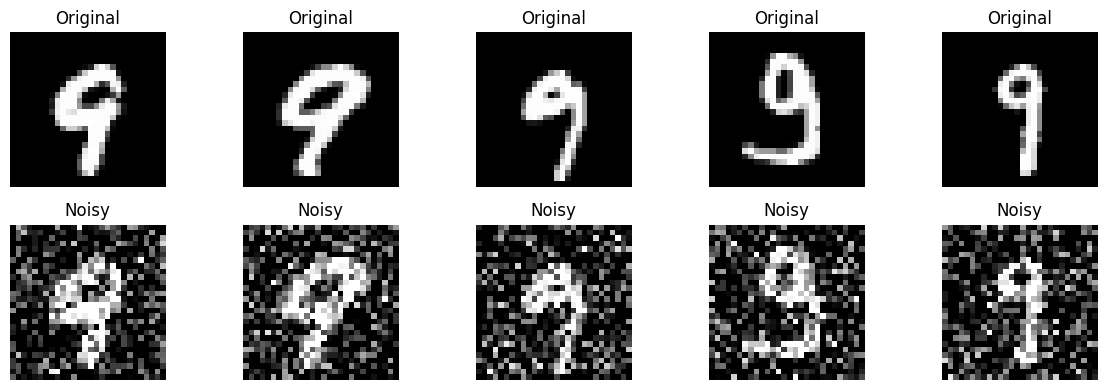

In [7]:
plt.figure(figsize=(12,4))
for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")
    # Noisy
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Build Denoising Autoencoder

In [8]:
input_img = Input(shape=(28,28,1))
# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)
# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)
autoencoder = Model(input_img, decoded) 
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

## 8. Train Model

In [10]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - loss: 0.1404 - val_loss: 0.1109
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - loss: 0.0962 - val_loss: 0.1036
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - loss: 0.0919 - val_loss: 0.1011
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - loss: 0.0898 - val_loss: 0.0995
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - loss: 0.0884 - val_loss: 0.0975
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - loss: 0.0875 - val_loss: 0.0967
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - loss: 0.0868 - val_loss: 0.0957
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - loss: 0.0862 - val_loss: 0.0954
Epoch 9/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - loss: 0.0857 - val_loss: 0.0949
Epoch 10/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - loss: 0.0854 - val_loss: 0.0947
Epoch 11/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - loss: 0.0849 - val_loss: 0.0942
Epoch 12/15
422/422 ━━━━━━━━━━

## 9. Denoise Test Images

In [11]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


## 10. Compare Original vs Noisy vs Denoised

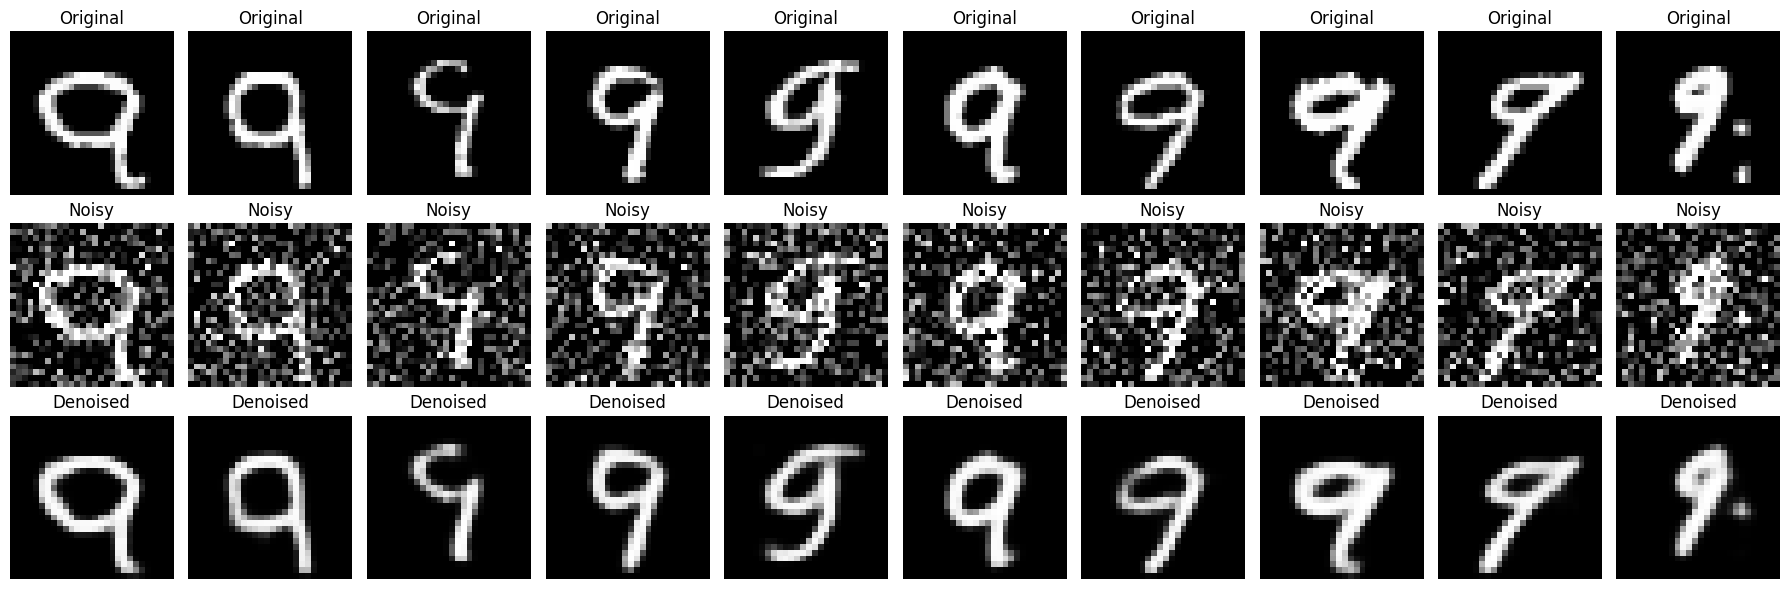

In [12]:
n = 10
plt.figure(figsize=(18,6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 11. Training Loss Curve

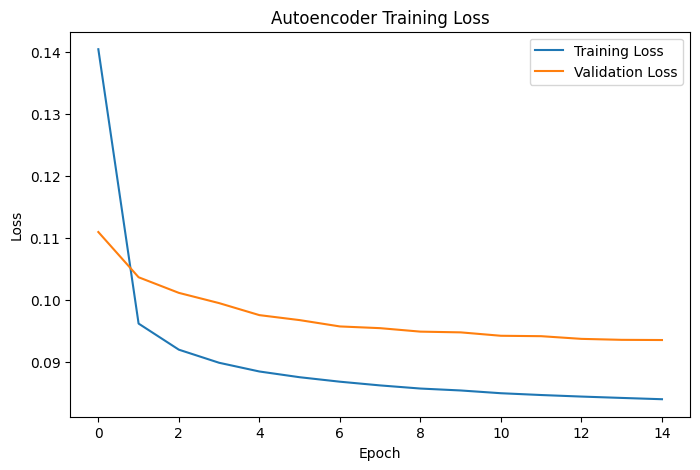

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()

## 12. Innovation Experiment

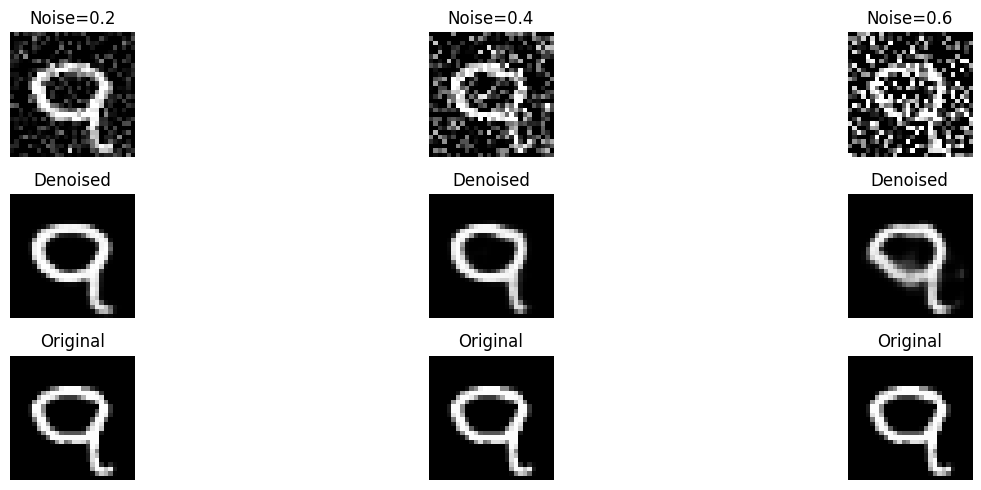

In [14]:
noise_levels = [0.2, 0.4, 0.6]
plt.figure(figsize=(15,5))
for idx, noise in enumerate(noise_levels):
    noisy = x_test[:1] + noise * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_test[:1].shape
    )
    noisy = np.clip(noisy, 0., 1.)
    denoised = autoencoder.predict(noisy, verbose=0)
    plt.subplot(3, len(noise_levels), idx + 1)
    plt.imshow(noisy[0].squeeze(), cmap="gray")
    plt.title(f"Noise={noise}")
    plt.axis("off")
    plt.subplot(3, len(noise_levels), idx + 1 + len(noise_levels))
    plt.imshow(denoised[0].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    plt.subplot(3, len(noise_levels), idx + 1 + 2*len(noise_levels))
    plt.imshow(x_test[0].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

1. The denoising autoencoder was able to convert noisy handwritten digit images into much cleaner images.

2. The encoder reduced the image size while keeping the important details of each digit.

3. The decoder successfully reconstructed the digits and removed most of the added Gaussian noise.

4. During training, both the training loss and validation loss gradually decreased, showing that the model learned effectively.

5. As the amount of noise increased, the reconstructed images became slightly less clear, but the digits could still be recognized.

## Conclusion

In this experiment, a convolutional denoising autoencoder was trained on the MNIST dataset to remove Gaussian noise from handwritten digit images. The model produced clear reconstructed images while maintaining the main features of the digits. The results show that denoising autoencoders are useful for image cleaning and can learn meaningful patterns even from noisy data.
